In [2]:
import datalair
import scanpy.external.pp
import singlecellrnasignature
from pathlib import Path
import anndata as ad
import scanpy as sc
import pandas as pd
from pyensembl import EnsemblRelease
import numpy as np
import matplotlib.pyplot as plt

In [3]:
lair_path = Path("/storage/halu/lair")
assert lair_path.exists()
lair = datalair.Lair(lair_path)

In [4]:
ds = singlecellrnasignature.raw.ZhangSinglecellAnalysisReveals2022()
lair.safe_derive(ds, overwrite=False)
lair.get_dataset_filepaths(ds)["GSE215120_RAW.tar"]

PosixPath('/storage/halu/lair/DatasetscRNASeqSignature-ZhangSinglecellAnalysisReveals2022/GSE215120_RAW.tar')

In [5]:
ds = singlecellrnasignature.adata.ZhangSinglecellAnalysisReveals2022Adata()
lair.safe_derive(ds, overwrite=False)

In [6]:
def calc_cell_cycle_scores(adata):
	# Download the gene list (Standard Tirosh 2016 list)
	# https://scanpy.readthedocs.io/en/latest/how-to/cell-cycle.html
	url = "https://raw.githubusercontent.com/theislab/scanpy_usage/master/180209_cell_cycle/data/regev_lab_cell_cycle_genes.txt"
	cell_cycle_genes = pd.read_csv(url, header=None)[0].tolist()
	gene_name_mapping = {"MLF1IP": "CENPU", "FAM64A": "PICALM", "HN1": "JPT1"}
	cell_cycle_genes = [gene_name_mapping.get(gene_name, gene_name) for gene_name in cell_cycle_genes]
	ensembl = EnsemblRelease(111)
	cell_cycle_genes = [ensembl.genes_by_name(gene_name)[0].gene_id for gene_name in cell_cycle_genes]
	s_genes = cell_cycle_genes[:43]
	g2m_genes = cell_cycle_genes[43:]
	sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

def preprocess(adata):
	adata.obs["total_count"] = adata.X.sum(axis=1)
	adata.obs["melanoma"] = adata.obs["patient_id"].apply(lambda x: x[:2])
	sc.pp.filter_cells(adata, min_genes=200)
	sc.pp.filter_genes(adata, min_cells=3)
	sc.pp.normalize_total(adata, target_sum=1e4)
	sc.pp.log1p(adata)
	calc_cell_cycle_scores(adata)
	# sc.pp.scale(adata, max_value=10)

def postprocess(adata):
	sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="patient_id")
	sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)
	sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50)

adata = ad.read_h5ad(lair.get_dataset_filepaths(ds)["adata.h5ad"])
adata.obs_names_make_unique()
preprocess(adata)

/home/halu/code/tme_analysis/.venv/lib/python3.14/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
adata.obs

,geo_id,patient_id,total_count,melanoma,n_genes,S_score,G2M_score,phase
AAACCCAAGAAACTAC-1,GSM6622302,CM1,3443,CM,1019,-0.096129,-0.104558,G1
AAACCCAAGGCAGCTA-1,GSM6622302,CM1,3431,CM,1664,-0.126437,-0.127694,G1
AAACCCAAGTGATCGG-1,GSM6622302,CM1,681,CM,339,0.024480,0.087204,G2M
AAACCCAAGTGCGCTC-1,GSM6622302,CM1,38943,CM,5723,-0.063056,-0.026118,G1
AAACCCACACCTGCGA-1,GSM6622302,CM1,4697,CM,1655,-0.023902,0.187706,G2M
...,...,...,...,...,...,...,...,...
TTTGTTGGTTGTCTAG-1,GSM6622301,CM3,30155,CM,5553,0.022065,1.038896,G2M
TTTGTTGTCCCTAGGG-1,GSM6622301,CM3,4568,CM,1796,-0.155532,-0.111941,G1
TTTGTTGTCGCCAACG-1,GSM6622301,CM3,7212,CM,2505,-0.150605,-0.129756,G1
TTTGTTGTCGTAGCTA-1,GSM6622301,CM3,24782,CM,4914,0.110984,0.151651,G2M


In [172]:
ensembl = EnsemblRelease(111)
markers_name = {
    "Immune": ["PTPRC"],
    "Fibroblast": ["COL1A1", "COL1A2", "COL3A1"],
    "Inflammatory CAF": ["DPT", "CXCL12", "CFD", "IL6"],
    "Oxidative CAF": ["PDGFRA", "FN1"],
    "Matrix metalloproteinase CAF": ["TIMP1", "ADAM10"],
    "Transcriptional CAF": ["FN1", "COL1A2"],
    "Mitochondrial CAF": ["SDHA", "MT-CO1", "NDUFB8"],
    "Mycobacteria": ["TUBB", "FTH1"],
    "Macrophage": ["MRC1"],
    "Matrix CAF": ["COL11A1", "MMP11", "CTHRC1", "FAP"],
    "Endothelial": ["PECAM1"],
    "Melanoma": ["PMEL", "MLANA", "S100B", "SOX10"],
    'T-cell': ['CD3D', 'CD3E', 'CD3G', 'CD4', 'CD8A'],
    'B-cell': ['CD19', 'MS4A1'],
    'Myeloid': ['CD14', 'LYZ', 'ITGAM'],
    'NK': ['NCAM1', 'KLRB1'],
    "Pan-Myeloid": ["LYZ", "CD14", "AIF1", "FCER1G", "TYROBP"],
    "Monocytes (Classical)": ["S100A8", "S100A9", "VCAN", "FCN1"],
    "Monocytes (Non-classical)": ["FCGR3A", "MS4A7", "LST1"],
    "Macrophages (General)": ["CD68", "CD14", "CD163", "CSF1R", "ADGRE1"],
    "TAMs (M2-like)": ["MRC1", "MERTK", "C1QA", "APOE", "MS4A6A", "CXCL8", "TGFBI"],
    "TAMs (M1-like)": ["NOS2", "CD80", "CXCL10", "IDO1"],
    "cDC1 (Cross-presenting)": ["CLEC9A", "XCR1", "BATF3", "CADM1"],
    "cDC2 (Antigen-presenting)": ["CD1C", "FCER1A", "CLEC10A", "HLA-DQA1"],
    "pDC (Interferon)": ["CLEC4C", "LILRA4", "TCF4", "IRF7"],
    "mregDC (Migratory)": ["LAMP3", "CCR7", "CD40", "BIRC3"],
    "Neutrophils": ["S100A12", "FCGR3B", "CXCR1", "CXCR2", "NAMPT"],
    "Mast Cells": ["TPSAB1", "TPSB2", "CPA3", "MS4A2", "KIT"],
    "MDSC-like": ["S100A11", "ARG1", "S100A12"]
}
markers_id_dict = {celltype: [ensembl.genes_by_name(gene_name)[0].gene_id for gene_name in gene_list] for celltype, gene_list in markers_name.items()}
markers_id = {gene_name: ensembl.genes_by_name(gene_name)[0].gene_id for gene_list in markers_name.values() for gene_name in gene_list}

... storing 'melanoma' as categorical
... storing 'phase' as categorical
/tmp/ipykernel_1285128/1963651320.py:26: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)


['Endothelial' 'Fibroblast' 'Immune' 'Melanoma']


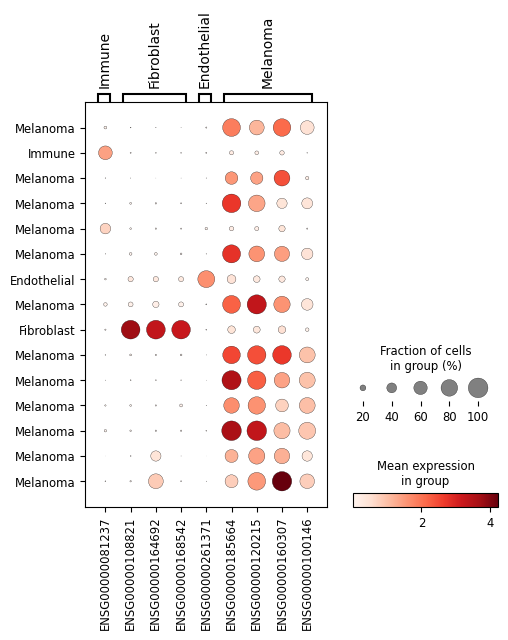

In [173]:
postprocess(adata)
leiden_key= "leiden_0"
sc.tl.leiden(adata, key_added=leiden_key, resolution=0.2, flavor="igraph")
marker_dict = {celltype: markers_id_dict[celltype] for celltype in ["Immune", "Fibroblast", "Endothelial", "Melanoma"]}
plot = sc.pl.dotplot(adata, marker_dict, groupby=leiden_key, return_fig=True)
labels = ["Melanoma", "Immune", "Melanoma", "Melanoma", "Melanoma", "Melanoma", "Endothelial", "Melanoma", "Fibroblast", "Melanoma", "Melanoma", "Melanoma", "Melanoma", "Melanoma", "Melanoma"]
print(np.unique(labels))
_ = plot.get_axes()["mainplot_ax"].set_yticklabels(labels)
adata.obs["celltype_0"] = adata.obs[leiden_key].apply(lambda i: labels[int(i)])

In [174]:
immune = adata[adata.obs["celltype_0"]=="Immune"]
postprocess(immune)
leiden_key= "leiden_1"
sc.tl.leiden(immune, key_added=leiden_key, resolution=2.0, flavor="igraph")

/home/halu/code/tme_analysis/.venv/lib/python3.14/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'celltype_0' as categorical
/tmp/ipykernel_1285128/1963651320.py:26: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)


... storing 'celltype_1' as categorical


['Myeloid' 'NK' 'T-cell' 'UNKNOWN']


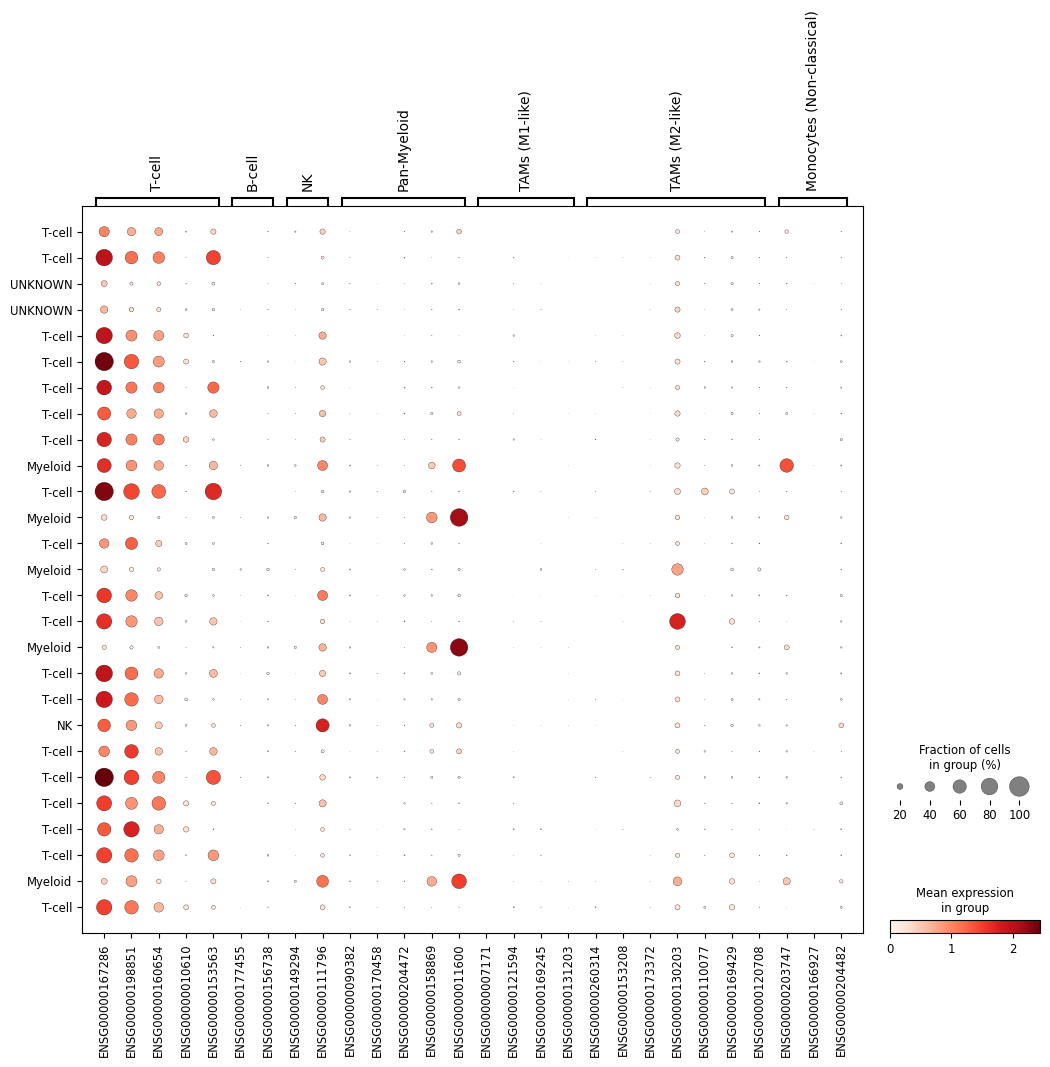

In [177]:
marker_dict = {celltype: markers_id_dict[celltype] for celltype in ["T-cell", "B-cell", "NK", "Pan-Myeloid", "TAMs (M1-like)", "TAMs (M2-like)", "Monocytes (Non-classical)"]}
plot = sc.pl.dotplot(immune, marker_dict, groupby=leiden_key, return_fig=True)
labels = ["T-cell", "T-cell", "UNKNOWN", "UNKNOWN", "T-cell", "T-cell", "T-cell", "T-cell", "T-cell", "Myeloid", "T-cell", "Myeloid", "T-cell", "Myeloid", "T-cell", "T-cell", "Myeloid", "T-cell", "T-cell", "NK", "T-cell", "T-cell", "T-cell", "T-cell", "T-cell", "Myeloid", "T-cell"]
print(np.unique(labels))
_ = plot.get_axes()["mainplot_ax"].set_yticklabels(labels)
immune.obs["celltype_1"] = immune.obs[leiden_key].apply(lambda i: labels[int(i)])

In [ ]:
sc.tl.umap(immune)

In [ ]:
sc.pl.umap(immune, color=leiden_key)

In [113]:
immune

AnnData object with n_obs × n_vars = 18494 × 27167
    obs: 'geo_id', 'patient_id', 'total_count', 'melanoma', 'n_genes', 'S_score', 'G2M_score', 'phase', 'leiden_0', 'celltype_0', 'leiden_1'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden_0', 'leiden_1'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'